# Preprocessing

the csv file that should be used in here is found in data\interim\

In [2]:
#import libraries
import pandas as pd

In [3]:
#load csv files
joined_df=pd.read_csv('../data/interim/joined_data.csv')

In [4]:
joined_df = joined_df.sort_values(by='date').reset_index(drop=True)

In [5]:
joined_df.tail()

,date,dou_code,meal_type_id,meal_items,n_distinct_items,meal_type,create_date,resto_name,id,id_pro,count,breakfast,launch,dinner
669923,2026-04-09,151,1,"حلويات جافة , حليب بالقهوة , عصير , ياغورت/قشدة",4,breakfast,2026-04-09,ANON_5c2150ddac80,363,5186172.0,496,50,233,213
669924,2026-04-09,151,1,"حلويات جافة , حليب بالقهوة , عصير , ياغورت/قشدة",4,breakfast,2026-04-09,ANON_a6fe8f441f2c,362,5186171.0,379,19,177,183
669925,2026-04-09,151,1,"حلويات جافة , حليب بالقهوة , عصير , ياغورت/قشدة",4,breakfast,2026-04-09,ANON_46abd12f70dd,52,5186173.0,80,15,3,62
669926,2026-04-09,151,2,"أرز مشكل , خبز , سلطة متنوعة , سمك/سردين معلب ...",6,lunch,2026-04-09,ANON_5c2150ddac80,363,5186172.0,496,50,233,213
669927,2026-04-09,481,3,"شوربة , لحم قطع في الفرن (لحم قطع + بطاطا بالص...",4,dinner,2026-04-09,ANON_93dd089ec13b,498,5186088.0,918,212,462,244


In [6]:
#look for null values in all columns 
null_values = joined_df.isnull().sum()
print(null_values)

date                    0
dou_code                0
meal_type_id            0
meal_items              0
n_distinct_items        0
meal_type               0
create_date             0
resto_name              0
id                      0
id_pro              12304
count                   0
breakfast               0
launch                  0
dinner                  0
dtype: int64


In [7]:
#drop useless columns
columns_to_drop = ['meal_type','id_pro','id','count','create_date','n_distinct_items']
joined_df = joined_df.drop(columns=columns_to_drop)

In [8]:
#find the cardinality of each column
cardinality = joined_df.nunique()
print(cardinality)

date              734
dou_code           66
meal_type_id        3
meal_items      48638
resto_name        506
breakfast         941
launch           2336
dinner           1922
dtype: int64


In [9]:
mapping_df = pd.read_csv('meal_items_mapping_cleaned.csv')

In [10]:
mapping_df.tail()

,item,category_id,category_name
3777,يعورت معطر,11,Dairy & Cheese
3778,يعورت معطرة,11,Dairy & Cheese
3779,يغورت معطر,11,Dairy & Cheese
3780,ڤراتان,11,Cooked Dishes & Stews
3781,ڨراته,11,Cooked Dishes & Stews


In [11]:
item_to_cat = dict(zip(mapping_df['item'].str.strip(), mapping_df['category_name']))

In [12]:
all_16_categories = mapping_df['category_name'].unique()

In [13]:
import re
def map_meal_to_categories(meal_text):
    if pd.isna(meal_text):
        return []
        
    # Split by +, /, commas, parentheses, or the Arabic words for "and" (و) / "or" (او/أو)
    parts = re.split(r'[\+\/\(\)\،\,]| او | أو | و ', str(meal_text))
    
    # Clean spaces and drop empty strings
    cleaned_items = [p.strip() for p in parts if p.strip()]
    
    # Map to categories 
    # (We use a 'set' because if a meal has two types of fruit, we only want one "Fruits" flag, not two)
    categories = set()
    for item in cleaned_items:
        cat = item_to_cat.get(item)
        if cat:
            categories.add(cat)
            
    return list(categories)

In [14]:
joined_df['category_list'] = joined_df['meal_items'].apply(map_meal_to_categories)

In [15]:
# Generate the 16 binary columns
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer(classes=all_16_categories)
binary_matrix = mlb.fit_transform(joined_df['category_list'])

In [16]:
# Convert the matrix into a DataFrame with the 16 category names as headers
binary_df = pd.DataFrame(binary_matrix, columns=mlb.classes_, index=joined_df.index)

In [17]:
joined_df = pd.concat([joined_df, binary_df], axis=1)

In [18]:
joined_df.head()

,date,dou_code,meal_type_id,meal_items,resto_name,breakfast,launch,dinner,category_list,Bread & Bakery,...,Eggs,Dairy & Cheese,Vegetables & Salads,Soups & Broths,Cooked Dishes & Stews,Potato Dishes,Fruits,Sweets & Desserts,Beverages,Condiments & Spreads
0,2023-12-12,41,1,"حليب بالقهوة , مادلان",ANON_beae590631b8,0,6,0,"[Beverages, Bread & Bakery]",1,...,0,0,0,0,0,0,0,0,1,0
1,2023-12-12,381,2,"ارز مفور , خبز , سلطة متنوعة , سمك , عصير",ANON_f70ee3e4559d,0,216,0,"[Fish & Seafood, Beverages, Bread & Bakery, Ri...",1,...,0,0,1,0,0,0,0,0,1,0
2,2023-12-12,381,1,"خبز بالشكولاطة , قهوة بالحليب",ANON_f70ee3e4559d,0,216,0,"[Beverages, Bread & Bakery]",1,...,0,0,0,0,0,0,0,0,1,0
3,2023-12-12,141,3,"تحلية , خبز , سلطة جزائرية , عصيدة بطاطس , كري...",ANON_294c1f5ad3ee,0,2,0,"[Red Meat, Vegetables & Salads, Sweets & Desse...",1,...,0,0,1,0,0,0,0,1,0,0
4,2023-12-12,141,2,"أرز بالفرن , تحلية , جبن , خبز , سلطة متنوعة",ANON_294c1f5ad3ee,0,2,0,"[Dairy & Cheese, Bread & Bakery, Rice & Pasta,...",1,...,0,1,1,0,0,0,0,1,0,0


In [19]:
# change data type of date column to string to be used later on as a categorical feature 
joined_df['date'] = joined_df['date'].astype(str)

In [20]:
#drop other useless columns
columns_to_drop = ['meal_type_id','category_list','meal_items']
joined_df = joined_df.drop(columns=columns_to_drop)

we drop meal_type_id since we are going to use MultiOutputRegressor and have a model for each target, one model for each meal type and the models are seperated so it will not provide any information

features b5laf meal_items are left unchanged because they are natevily handled by catboost and they have relatively low cardinality

In [20]:
print("Breakfast rows with 0:", joined_df[joined_df['breakfast'] == 0].shape[0])
print("Lunch rows with 0:", joined_df[joined_df['launch'] == 0].shape[0])
print("Dinner rows with 0:", joined_df[joined_df['dinner'] == 0].shape[0])

Breakfast rows with 0: 192407
Lunch rows with 0: 22336
Dinner rows with 0: 112565


In [21]:
joined_df[joined_df['launch'] == 0 & (joined_df['breakfast'] == 0) & (joined_df['dinner'] == 0)].shape[0]

22336

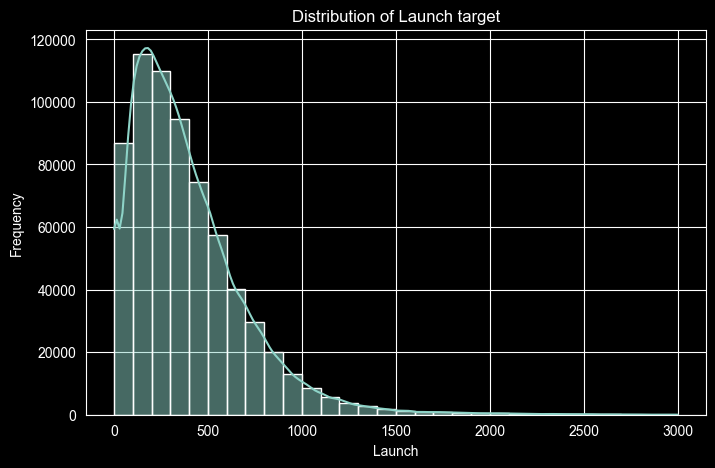

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
# Histogram + KDE
plt.figure(figsize=(8, 5))
sns.histplot(joined_df["launch"], bins=30, kde=True)

plt.title("Distribution of Launch target")
plt.xlabel("Launch")
plt.ylabel("Frequency")

plt.show()

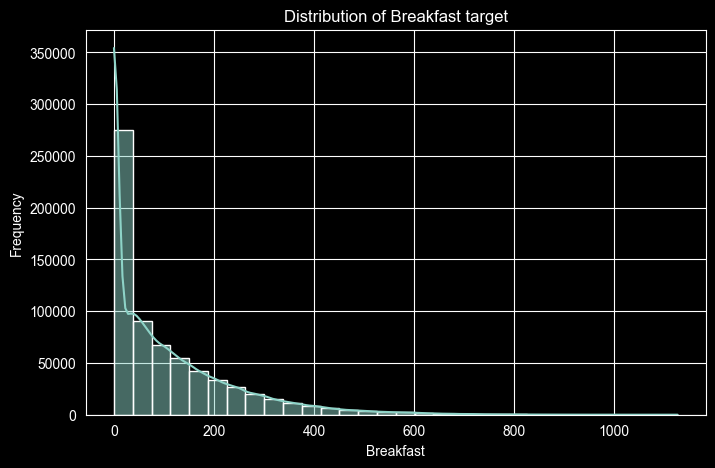

In [23]:

import matplotlib.pyplot as plt
import seaborn as sns
# Histogram + KDE
plt.figure(figsize=(8, 5))
sns.histplot(joined_df["breakfast"], bins=30, kde=True)

plt.title("Distribution of Breakfast target")
plt.xlabel("Breakfast")
plt.ylabel("Frequency")

plt.show()

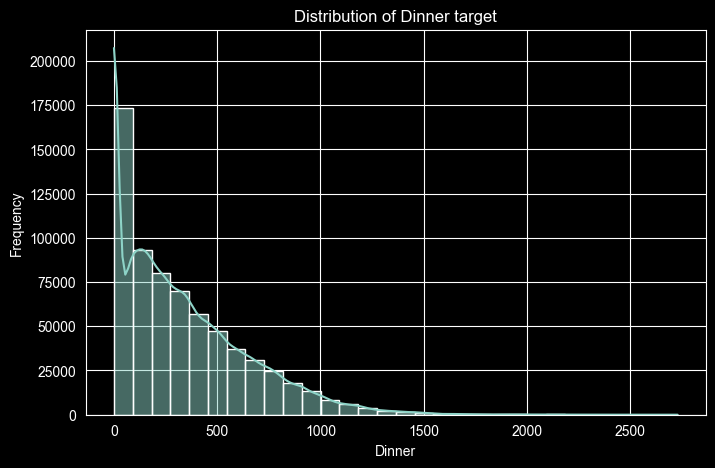

In [24]:

import matplotlib.pyplot as plt
import seaborn as sns
# Histogram + KDE
plt.figure(figsize=(8, 5))
sns.histplot(joined_df["dinner"], bins=30, kde=True)

plt.title("Distribution of Dinner target")
plt.xlabel("Dinner")
plt.ylabel("Frequency")

plt.show()

ADD A LOG TRANSFORMATION HERE

In [21]:
#create a log transformation of the target variables to reduce skewness using sklearn transformers
from sklearn.preprocessing import FunctionTransformer
import numpy as np

log_transformer = FunctionTransformer(func=lambda x: np.log1p(x), inverse_func=lambda x: np.expm1(x))  



In [22]:
#create a column transformer to apply the log transformation to the target variables
from sklearn.compose import ColumnTransformer


column_transformer = ColumnTransformer(
    transformers=[
        ('log', log_transformer, ['breakfast', 'launch', 'dinner'])
    ]
)

# Feature engineering

feature engineering using sklearn transformers to create new features from the date column such as day of week, month, year, is_weekend
from sklearn.base import BaseEstimator, TransformerMixin

In [23]:
# dataframe head
joined_df.head()

,date,dou_code,resto_name,breakfast,launch,dinner,Bread & Bakery,Rice & Pasta,Legumes,Poultry,...,Eggs,Dairy & Cheese,Vegetables & Salads,Soups & Broths,Cooked Dishes & Stews,Potato Dishes,Fruits,Sweets & Desserts,Beverages,Condiments & Spreads
0,2023-12-12,41,ANON_beae590631b8,0,6,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,2023-12-12,381,ANON_f70ee3e4559d,0,216,0,1,1,0,0,...,0,0,1,0,0,0,0,0,1,0
2,2023-12-12,381,ANON_f70ee3e4559d,0,216,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,2023-12-12,141,ANON_294c1f5ad3ee,0,2,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,2023-12-12,141,ANON_294c1f5ad3ee,0,2,0,1,1,0,0,...,0,1,1,0,0,0,0,1,0,0


In [24]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, date_column='date'):
        self.date_column = date_column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # convert to datetime
        dates = pd.to_datetime(X[self.date_column])

        # basic date parts
        day_of_week = dates.dt.dayofweek
        day_of_month = dates.dt.day

        X['month'] = dates.dt.month
        X['year'] = dates.dt.year

        X['is_weekend'] = day_of_week.isin([4, 5]).astype(int)
        X['is_month_start'] = dates.dt.is_month_start.astype(int)
        X['is_month_end'] = dates.dt.is_month_end.astype(int)

        # cyclic encoding for day_of_week (0-6)
        X['day_of_week_sin'] = np.sin(2 * np.pi * day_of_week / 7)
        X['day_of_week_cos'] = np.cos(2 * np.pi * day_of_week / 7)

        # cyclic encoding for day_of_month (1-31)
        X['day_of_month_sin'] = np.sin(2 * np.pi * day_of_month / 31)
        X['day_of_month_cos'] = np.cos(2 * np.pi * day_of_month / 31)

        #cyclic encoding for month (1-12)
        X['month_sin'] = np.sin(2 * np.pi * X['month'] / 12)
        X['month_cos'] = np.cos(2 * np.pi * X['month'] / 12)

        # drop original date column
        X = X.drop(columns=[self.date_column])

        return X

In [25]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class LagFeatureCreator(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        date_column='date',
        target_column='count',
        group_column='restaurant_name',
        last_day_lag=1,
        last_week_lag=7
    ):
        self.date_column = date_column
        self.target_column = target_column
        self.group_column = group_column
        self.last_day_lag = last_day_lag
        self.last_week_lag = last_week_lag

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # sort by restaurant and date
        X = X.sort_values([self.group_column, self.date_column])

        # lag features
        X['last_day_count'] = (
            X.groupby(self.group_column)[self.target_column]
            .shift(self.last_day_lag)
            .fillna(0)
        )

        X['last_week_count'] = (
            X.groupby(self.group_column)[self.target_column]
            .shift(self.last_week_lag)
            .fillna(0)
        )

        return X

In [26]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class ExpandingAverageFeatureCreator(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        date_column='date',
        target_column='count',
        group_column='restaurant_name'
    ):
        self.date_column = date_column
        self.target_column = target_column
        self.group_column = group_column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # sort correctly
        X = X.sort_values([self.group_column, self.date_column])

        # average from first row to T-1
        X['avg_previous_count'] = (
            X.groupby(self.group_column)[self.target_column]
            .transform(
                lambda s: s.shift(1).expanding().mean()
            )
            .fillna(0)
        )

        return X

In [27]:
# create a copy of the dataframe to apply the feature engineering on it
feature_engineered_df = joined_df.copy()

# drop breakfast, launch, dinner columns to apply the feature engineering on the original count column and then we will drop the count column after creating the features
feature_engineered_df['count'] = feature_engineered_df['breakfast'] + feature_engineered_df['launch'] + feature_engineered_df['dinner']
feature_engineered_df.drop(columns=['breakfast', 'launch', 'dinner'], inplace=True)

In [28]:
feature_engineered_df.head()

,date,dou_code,resto_name,Bread & Bakery,Rice & Pasta,Legumes,Poultry,Red Meat,Fish & Seafood,Eggs,Dairy & Cheese,Vegetables & Salads,Soups & Broths,Cooked Dishes & Stews,Potato Dishes,Fruits,Sweets & Desserts,Beverages,Condiments & Spreads,count
0,2023-12-12,41,ANON_beae590631b8,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,6
1,2023-12-12,381,ANON_f70ee3e4559d,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,216
2,2023-12-12,381,ANON_f70ee3e4559d,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,216
3,2023-12-12,141,ANON_294c1f5ad3ee,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,2
4,2023-12-12,141,ANON_294c1f5ad3ee,1,1,0,0,0,0,0,1,1,0,0,0,0,1,0,0,2


In [29]:
selected_cols = ['date', 'resto_name', 'count']

feature_engineered_df = feature_engineered_df[selected_cols]
feature_engineered_df.head()

,date,resto_name,count
0,2023-12-12,ANON_beae590631b8,6
1,2023-12-12,ANON_f70ee3e4559d,216
2,2023-12-12,ANON_f70ee3e4559d,216
3,2023-12-12,ANON_294c1f5ad3ee,2
4,2023-12-12,ANON_294c1f5ad3ee,2


In [30]:
# apply the date feature extractor
date_extractor = DateFeatureExtractor(date_column='date')

# copy of the dataframe to apply the date feature extractor on it
feature_engineered_df_date = feature_engineered_df.copy()
feature_engineered_df_date = date_extractor.fit_transform(feature_engineered_df_date)
feature_engineered_df_date.head()

,resto_name,count,month,year,is_weekend,is_month_start,is_month_end,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,month_sin,month_cos
0,ANON_beae590631b8,6,12,2023,0,0,0,0.781831,0.62349,0.651372,-0.758758,-2.449294e-16,1.0
1,ANON_f70ee3e4559d,216,12,2023,0,0,0,0.781831,0.62349,0.651372,-0.758758,-2.449294e-16,1.0
2,ANON_f70ee3e4559d,216,12,2023,0,0,0,0.781831,0.62349,0.651372,-0.758758,-2.449294e-16,1.0
3,ANON_294c1f5ad3ee,2,12,2023,0,0,0,0.781831,0.62349,0.651372,-0.758758,-2.449294e-16,1.0
4,ANON_294c1f5ad3ee,2,12,2023,0,0,0,0.781831,0.62349,0.651372,-0.758758,-2.449294e-16,1.0


In [31]:
# apply the lag feature creator
lag_creator = LagFeatureCreator(
    date_column='date',
    target_column='count',
    group_column='resto_name',
    last_day_lag=1,
    last_week_lag=7
)

feature_engineered_df_lag = feature_engineered_df.copy()
feature_engineered_df_lag = lag_creator.fit_transform(feature_engineered_df_lag)
feature_engineered_df_lag.head()

,date,resto_name,count,last_day_count,last_week_count
1643,2024-01-08,ANON_0035909ef97c,3,0.0,0.0
1646,2024-01-08,ANON_0035909ef97c,3,3.0,0.0
1680,2024-01-08,ANON_0035909ef97c,3,3.0,0.0
2017,2024-01-09,ANON_0035909ef97c,127,3.0,0.0
2094,2024-01-09,ANON_0035909ef97c,127,127.0,0.0


In [32]:
# apply the expanding average feature creator
expanding_avg_creator = ExpandingAverageFeatureCreator(
    date_column='date',
    target_column='count',
    group_column='resto_name'
)

feature_engineered_df_expanding_avg = feature_engineered_df.copy()
feature_engineered_df_expanding_avg = expanding_avg_creator.fit_transform(feature_engineered_df_expanding_avg)
feature_engineered_df_expanding_avg.head()

,date,resto_name,count,avg_previous_count
1643,2024-01-08,ANON_0035909ef97c,3,0.0
1646,2024-01-08,ANON_0035909ef97c,3,3.0
1680,2024-01-08,ANON_0035909ef97c,3,3.0
2017,2024-01-09,ANON_0035909ef97c,127,3.0
2094,2024-01-09,ANON_0035909ef97c,127,34.0
